In [1]:
from arch import arch_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings as _warnings
from scipy.optimize import minimize
from scipy.stats import norm as _snorm, t as _st
try:
    from tqdm.auto import tqdm
except ModuleNotFoundError:
    def tqdm(it, **kwargs): return it
from pathlib import Path

output_path = Path(".")  # save figures here


In [2]:
DATA_PATH = "/Users/vilgotparsmo/Documents/GitHub/TMS088/Data/spiff_data-2.csv"  # adjust path if needed

prices_raw = pd.read_csv(DATA_PATH, index_col=0)
prices_raw.index = prices_raw.index.astype(int)
prices_raw.index.name = "day"

# Remove implausible values (all assets = 1000)
prices = prices_raw.copy()
prices[prices == 1000] = np.nan
if "day" in prices.columns:
    prices = prices.drop(columns=["day"])

TRAILING_START = 5257
N_STEPS        = 200

# Build trailing_gaps table manually
trailing_gaps = pd.DataFrame([
    {"series": col, "start": TRAILING_START, "length": N_STEPS, "gap_type": "trailing"}
    for col in prices.columns
])

print(f"Loaded {prices.shape[0]} days x {prices.shape[1]} assets")
print(f"Assets: {list(prices.columns)}")
print(f"Trailing gap: days {TRAILING_START}-{TRAILING_START + N_STEPS - 1}")
trailing_gaps


Loaded 5456 days x 7 assets
Assets: ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
Trailing gap: days 5257-5456


,series,start,length,gap_type
0,gurkor,5257,200,trailing
1,guitars,5257,200,trailing
2,slingshots,5257,200,trailing
3,stocks,5257,200,trailing
4,sugar,5257,200,trailing
5,water,5257,200,trailing
6,tranquillity,5257,200,trailing


## Task 3: Extrapolation

Unlike the internal gaps in Task 2, trailing gaps have **no right endpoint** — there is nothing to pin paths to. This means we cannot use a Brownian bridge; instead we do a pure forward extrapolation from the last observed price.

Two methods are evaluated:
1. **Single-series GARCH(1,1)-t** — each series modelled independently.
2. **DCC-GARCH(1,1)-t** — all series modelled jointly to preserve cross-series correlation.


In [3]:
def garch_extrapolation(
    price_series: pd.Series,
    start_day,
    n_steps: int,
    calibration_window: int = 400,
    n_simulations: int = 1000,
    random_seed=None,
) -> dict:
    """
    Extrapolate a trailing gap using GARCH(1,1)-t forward simulation.
    No bridge correction since right endpoint is unknown.
    Uses arch package for GARCH fitting (consistent with Task 2).
    """
    MIN_OBS = 20
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().dropna().copy()

    pre = series[series.index < start_day]
    if len(pre) == 0:
        raise ValueError("No observations before start_day.")

    anchor_price = float(pre.iloc[-1])

    # Log-returns for calibration
    log_rets = np.log(pre / pre.shift(1)).dropna().iloc[-calibration_window:]
    if len(log_rets) < MIN_OBS:
        raise ValueError(f"Need >={MIN_OBS} pre-gap log-returns, got {len(log_rets)}.")

    # Fit GARCH(1,1)-t using arch (consistent with Task 2 single-series method)
    with _warnings.catch_warnings():
        _warnings.simplefilter("ignore")
        model  = arch_model(log_rets.values * 100, mean="Zero",
                            vol="GARCH", p=1, q=1,
                            dist="StudentsT", rescale=False)
        result = model.fit(disp="off", show_warning=False)

    _p = result.params
    nu = float(_p.get("nu", 8.0))
    try:
        alpha = float(_p["alpha[1]"])
        beta  = float(_p["beta[1]"])
    except KeyError:
        alpha = next((float(v) for k, v in _p.items() if "alpha" in k.lower()), np.nan)
        beta  = next((float(v) for k, v in _p.items() if "beta"  in k.lower()), np.nan)
    if not (np.isfinite(nu) and nu > 2.05):
        nu = 8.0

    # Forecast conditional variances (mean-revert toward unconditional level)
    fc        = result.forecast(horizon=n_steps, reindex=False)
    variances = fc.variance.iloc[-1].to_numpy(dtype=float) / 1e4

    if not np.isfinite(variances).all() or np.any(variances <= 0):
        variances = np.full(n_steps, float(log_rets.std()) ** 2)

    gap_index = pd.RangeIndex(start=int(start_day), stop=int(start_day) + n_steps)

    # Simulate paths with Student-t innovations scaled by GARCH conditional std
    dof    = nu
    z      = (rng.standard_t(dof, size=(n_simulations, n_steps))
               * np.sqrt((dof - 2.0) / dof))
    shocks = z * np.sqrt(variances)[None, :]

    log_paths = np.log(anchor_price) + np.cumsum(shocks, axis=1)
    paths     = np.exp(log_paths)

    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T, index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([series, gap_fill]).sort_index()

    return {
        "method":      "garch_extrapolation",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "nu":          nu,
        "alpha":       alpha,
        "beta":        beta,
        "variances":   variances,
    }


In [4]:
def dcc_garch_extrapolation(
    prices_df: pd.DataFrame,
    start_day,
    n_steps: int,
    calibration_window: int = 400,
    n_simulations: int = 1000,
    random_seed=None,
) -> dict:
    """
    Extrapolate all series jointly using DCC-GARCH(1,1)-t.
    Uses Gaussian copula with per-series t_nu marginals (correct approach).
    DCC parameters fit by QMLE with multi-start optimization.
    """
    MIN_OBS = 30
    rng          = np.random.default_rng(random_seed)
    series_names = list(prices_df.columns)
    k            = len(series_names)

    # Calibration log-returns
    all_lr  = np.log(prices_df / prices_df.shift(1))
    cal_pre = (
        all_lr[all_lr.index < start_day]
        .dropna()
        .iloc[-calibration_window:]
    )
    if len(cal_pre) < MIN_OBS:
        raise ValueError(f"Need >={MIN_OBS} calibration observations, got {len(cal_pre)}.")
    n_cal = len(cal_pre)

    # Fit GARCH(1,1)-t per series using arch (same as Task 2)
    def fit_garch_params(returns, series_name="?"):
        var      = float(np.var(returns)) or 1e-8
        fallback = (0.05 * var, 0.10, 0.85, 8.0, np.full(len(returns), var))
        try:
            with _warnings.catch_warnings():
                _warnings.simplefilter("ignore")
                res = arch_model(
                    returns * 100, mean="Zero", vol="GARCH",
                    p=1, q=1, dist="StudentsT", rescale=False,
                ).fit(disp="off", show_warning=False)
        except (ValueError, np.linalg.LinAlgError, FloatingPointError):
            return fallback
        if res.convergence_flag != 0:
            return fallback
        omega = float(res.params["omega"]) / 1e4
        alpha = float(res.params["alpha[1]"])
        beta  = float(res.params["beta[1]"])
        nu    = float(res.params.get("nu", 8.0))
        s2    = np.asarray(res.conditional_volatility) ** 2 / 1e4
        if (not np.isfinite([omega, alpha, beta]).all()
                or any(x < 0 for x in (omega, alpha, beta))
                or alpha + beta >= 1.0
                or not np.isfinite(s2).all() or (s2 <= 0).any()):
            return fallback
        return omega, alpha, beta, nu, s2

    garch_info = {}
    std_Z      = np.zeros((n_cal, k))
    for idx, s in enumerate(series_names):
        omega, alpha, beta, nu, s2 = fit_garch_params(cal_pre[s].values, s)
        garch_info[s] = dict(omega=omega, alpha=alpha, beta=beta, nu=nu,
                             last_s2=float(s2[-1]), last_r2=float(cal_pre[s].values[-1]**2))
        std_Z[:, idx] = np.clip(cal_pre[s].values / np.sqrt(s2), -6.0, 6.0)

    # DCC(1,1) QMLE on standardised residuals
    Q_bar = std_Z.T @ std_Z / n_cal
    d_bar = np.sqrt(np.maximum(np.diag(Q_bar), 1e-10))
    Q_bar_cor = Q_bar / np.outer(d_bar, d_bar)
    np.fill_diagonal(Q_bar_cor, 1.0)
    np.clip(Q_bar_cor, -0.9999, 0.9999, out=Q_bar_cor)
    np.fill_diagonal(Q_bar_cor, 1.0)

    def dcc_neg_loglik(params):
        a, b = params
        if a <= 0 or b <= 0 or a + b >= 1.0:
            return 1e12
        Q  = Q_bar_cor.copy()
        ll = 0.0
        for t in range(n_cal):
            z  = std_Z[t]
            dq = np.sqrt(np.maximum(np.diag(Q), 1e-10))
            R  = Q / np.outer(dq, dq)
            np.fill_diagonal(R, 1.0)
            try:
                sign, logdet = np.linalg.slogdet(R)
                if sign <= 0 or not np.isfinite(logdet):
                    return 1e12
                Rinvz = np.linalg.solve(R, z)
                if not np.isfinite(Rinvz).all():
                    return 1e12
                ll += logdet + z @ Rinvz - z @ z
            except np.linalg.LinAlgError:
                return 1e12
            Q = (1 - a - b) * Q_bar_cor + a * np.outer(z, z) + b * Q
        return 0.5 * ll if np.isfinite(ll) else 1e12

    # Multi-start optimization to avoid shallow local minima
    _best_val, _best_x = np.inf, np.array([0.05, 0.90])
    for _a0, _b0 in [(0.05, 0.90), (0.02, 0.95), (0.01, 0.50), (0.10, 0.70)]:
        if _a0 + _b0 >= 1.0:
            continue
        _r = minimize(
            dcc_neg_loglik, x0=[_a0, _b0], method="L-BFGS-B",
            bounds=[(1e-6, 0.30), (1e-6, 0.999)],
            options={"maxiter": 300},
        )
        if _r.fun < _best_val and float(_r.x[0]) + float(_r.x[1]) < 1.0:
            _best_val, _best_x = _r.fun, _r.x
    a_dcc = float(_best_x[0]) if np.isfinite(_best_val) else 0.05
    b_dcc = float(_best_x[1]) if np.isfinite(_best_val) else 0.90
    persistence = a_dcc + b_dcc

    # Last filtered DCC state Q_T
    Q_T = Q_bar_cor.copy()
    for t in range(n_cal):
        z   = std_Z[t]
        Q_T = (1 - a_dcc - b_dcc) * Q_bar_cor + a_dcc * np.outer(z, z) + b_dcc * Q_T
    if not np.isfinite(Q_T).all():
        Q_T = Q_bar_cor.copy()

    # GARCH h-step variance forecasts per series
    def garch_forecast(p, h):
        omega, alpha, beta = p["omega"], p["alpha"], p["beta"]
        s2, r2 = p["last_s2"], p["last_r2"]
        out = np.zeros(h)
        for i in range(h):
            s2 = omega + alpha * r2 + beta * s2
            if not (np.isfinite(s2) and s2 > 0):
                s2 = p["last_s2"]
            out[i] = s2
            r2 = s2
        return out

    garch_sigmas = np.zeros((k, n_steps))
    for idx, s in enumerate(series_names):
        fv = garch_forecast(garch_info[s], n_steps)
        garch_sigmas[idx] = np.sqrt(np.maximum(fv, 1e-12))

    # Per-series degrees of freedom and unit-variance t scale factors
    nu_arr  = np.array([garch_info[s]["nu"] for s in series_names])
    t_scale = np.sqrt((nu_arr - 2.0) / nu_arr)

    # Anchor log-prices
    anchor_logs = np.zeros(k)
    for idx, s in enumerate(series_names):
        obs = prices_df[s].dropna()
        anchor_logs[idx] = np.log(float(obs[obs.index < start_day].iloc[-1]))

    # Simulate correlated paths using Gaussian copula with t_nu marginals
    # This preserves per-series GARCH distributions while maintaining DCC correlation
    increments = np.zeros((n_simulations, n_steps, k))
    for h in range(n_steps):
        # Analytic DCC forecast: Q_bar + persistence^h * (Q_T - Q_bar)
        decay = persistence ** (h + 1)
        Q_h   = Q_bar_cor + decay * (Q_T - Q_bar_cor)
        dq    = np.sqrt(np.maximum(np.diag(Q_h), 1e-10))
        R_h   = Q_h / np.outer(dq, dq)
        np.fill_diagonal(R_h, 1.0)
        np.clip(R_h, -0.9999, 0.9999, out=R_h)
        np.fill_diagonal(R_h, 1.0)
        try:
            L_h = np.linalg.cholesky(R_h)
        except np.linalg.LinAlgError:
            eigvals, eigvecs = np.linalg.eigh(R_h)
            eigvals = np.maximum(eigvals, 1e-8)
            R_h = eigvecs @ np.diag(eigvals) @ eigvecs.T
            d   = np.sqrt(np.diag(R_h))
            R_h = R_h / np.outer(d, d)
            np.fill_diagonal(R_h, 1.0)
            L_h = np.linalg.cholesky(R_h)
        # Gaussian copula: correlated N(0,1) -> uniform -> t_nu per series
        eps     = rng.standard_normal((n_simulations, k))
        z_gauss = eps @ L_h.T
        u       = _snorm.cdf(z_gauss)
        np.clip(u, 1e-10, 1 - 1e-10, out=u)
        z = _st.ppf(u, df=nu_arr[None, :]) * t_scale[None, :]
        increments[:, h, :] = z * garch_sigmas[:, h][None, :]

    cum_inc   = np.cumsum(increments, axis=1)
    log_paths = anchor_logs[None, None, :] + cum_inc
    paths     = np.exp(log_paths)

    # Package per-series results (same format as garch_extrapolation)
    gap_index = pd.RangeIndex(start=int(start_day), stop=int(start_day) + n_steps)
    results   = {}
    for idx, s in enumerate(series_names):
        p           = paths[:, :, idx]
        median_path = np.median(p, axis=0)
        pct_values  = np.percentile(p, [5, 25, 50, 75, 95], axis=0)
        percentiles = pd.DataFrame(
            pct_values.T, index=gap_index,
            columns=["p5", "p25", "p50", "p75", "p95"],
        )
        obs         = prices_df[s].dropna()
        obs         = obs[obs.index < start_day]
        gap_fill    = pd.Series(median_path, index=gap_index, name=s)
        full_series = pd.concat([obs, gap_fill]).sort_index()
        results[s] = {
            "method":      "dcc_garch_extrapolation",
            "gap_index":   gap_index,
            "median":      median_path,
            "mean":        np.mean(p, axis=0),
            "std":         np.std(p, axis=0),
            "percentiles": percentiles,
            "simulations": p,
            "full_series": full_series,
            "nu":          garch_info[s]["nu"],
            "alpha":       garch_info[s]["alpha"],
            "beta":        garch_info[s]["beta"],
            "dcc_a":       a_dcc,
            "dcc_b":       b_dcc,
        }
    model_info = {
        "dcc_a": a_dcc, "dcc_b": b_dcc, "persistence": persistence,
        "Q_bar": Q_bar_cor, "Q_T": Q_T, "garch_info": garch_info,
    }
    return results, model_info


In [5]:
HISTORY_WINDOW = 400
N_COLS = 2
n_series = len(trailing_gaps)
n_rows   = (n_series + N_COLS - 1) // N_COLS

results = {}
for _, row in trailing_gaps.iterrows():
    name      = row["series"]
    start_day = row["start"]
    n_steps   = row["length"]
    res = garch_extrapolation(
        prices[name], start_day=start_day, n_steps=n_steps,
        calibration_window=400, n_simulations=2000, random_seed=42,
    )
    results[name] = res
    print(f"{name}: nu={res['nu']:.1f}, alpha={res['alpha']:.3f}, beta={res['beta']:.3f}")


gurkor: nu=14.2, alpha=0.000, beta=0.999
guitars: nu=5.3, alpha=0.040, beta=0.946
slingshots: nu=5.7, alpha=0.104, beta=0.814
stocks: nu=114.1, alpha=0.022, beta=0.000
sugar: nu=9.7, alpha=0.030, beta=0.970
water: nu=7.6, alpha=0.030, beta=0.957
tranquillity: nu=8.5, alpha=0.027, beta=0.942


In [6]:
_starts  = trailing_gaps["start"].unique()
_lengths = trailing_gaps["length"].unique()

if len(_starts) == 1 and len(_lengths) == 1:
    _res_joint, model_info = dcc_garch_extrapolation(
        prices, start_day=int(_starts[0]), n_steps=int(_lengths[0]),
        calibration_window=400, n_simulations=2000, random_seed=42,
    )
    dcc_all = {name: _res_joint[name] for name in trailing_gaps["series"]}
else:
    dcc_all = {}
    model_info = None
    for _, row in tqdm(trailing_gaps.iterrows(), total=len(trailing_gaps), desc="DCC per series"):
        name = row["series"]
        _res, model_info = dcc_garch_extrapolation(
            prices, start_day=int(row["start"]), n_steps=int(row["length"]),
            calibration_window=400, n_simulations=2000, random_seed=42,
        )
        dcc_all[name] = _res[name]

print(f"DCC a={model_info['dcc_a']:.4f}  b={model_info['dcc_b']:.4f}  "
      f"persistence={model_info['persistence']:.4f}")
print("\nPer-series GARCH parameters:")
for s, info in model_info["garch_info"].items():
    print(f"  {s:<14} nu={info['nu']:.2f}  alpha={info['alpha']:.3f}  beta={info['beta']:.3f}")


DCC a=0.0184  b=0.8374  persistence=0.8558

Per-series GARCH parameters:
  gurkor         nu=14.17  alpha=0.000  beta=0.999
  guitars        nu=5.29  alpha=0.040  beta=0.946
  slingshots     nu=5.69  alpha=0.104  beta=0.814
  stocks         nu=114.08  alpha=0.022  beta=0.000
  sugar          nu=9.72  alpha=0.030  beta=0.970
  water          nu=7.62  alpha=0.030  beta=0.957
  tranquillity   nu=8.52  alpha=0.027  beta=0.942


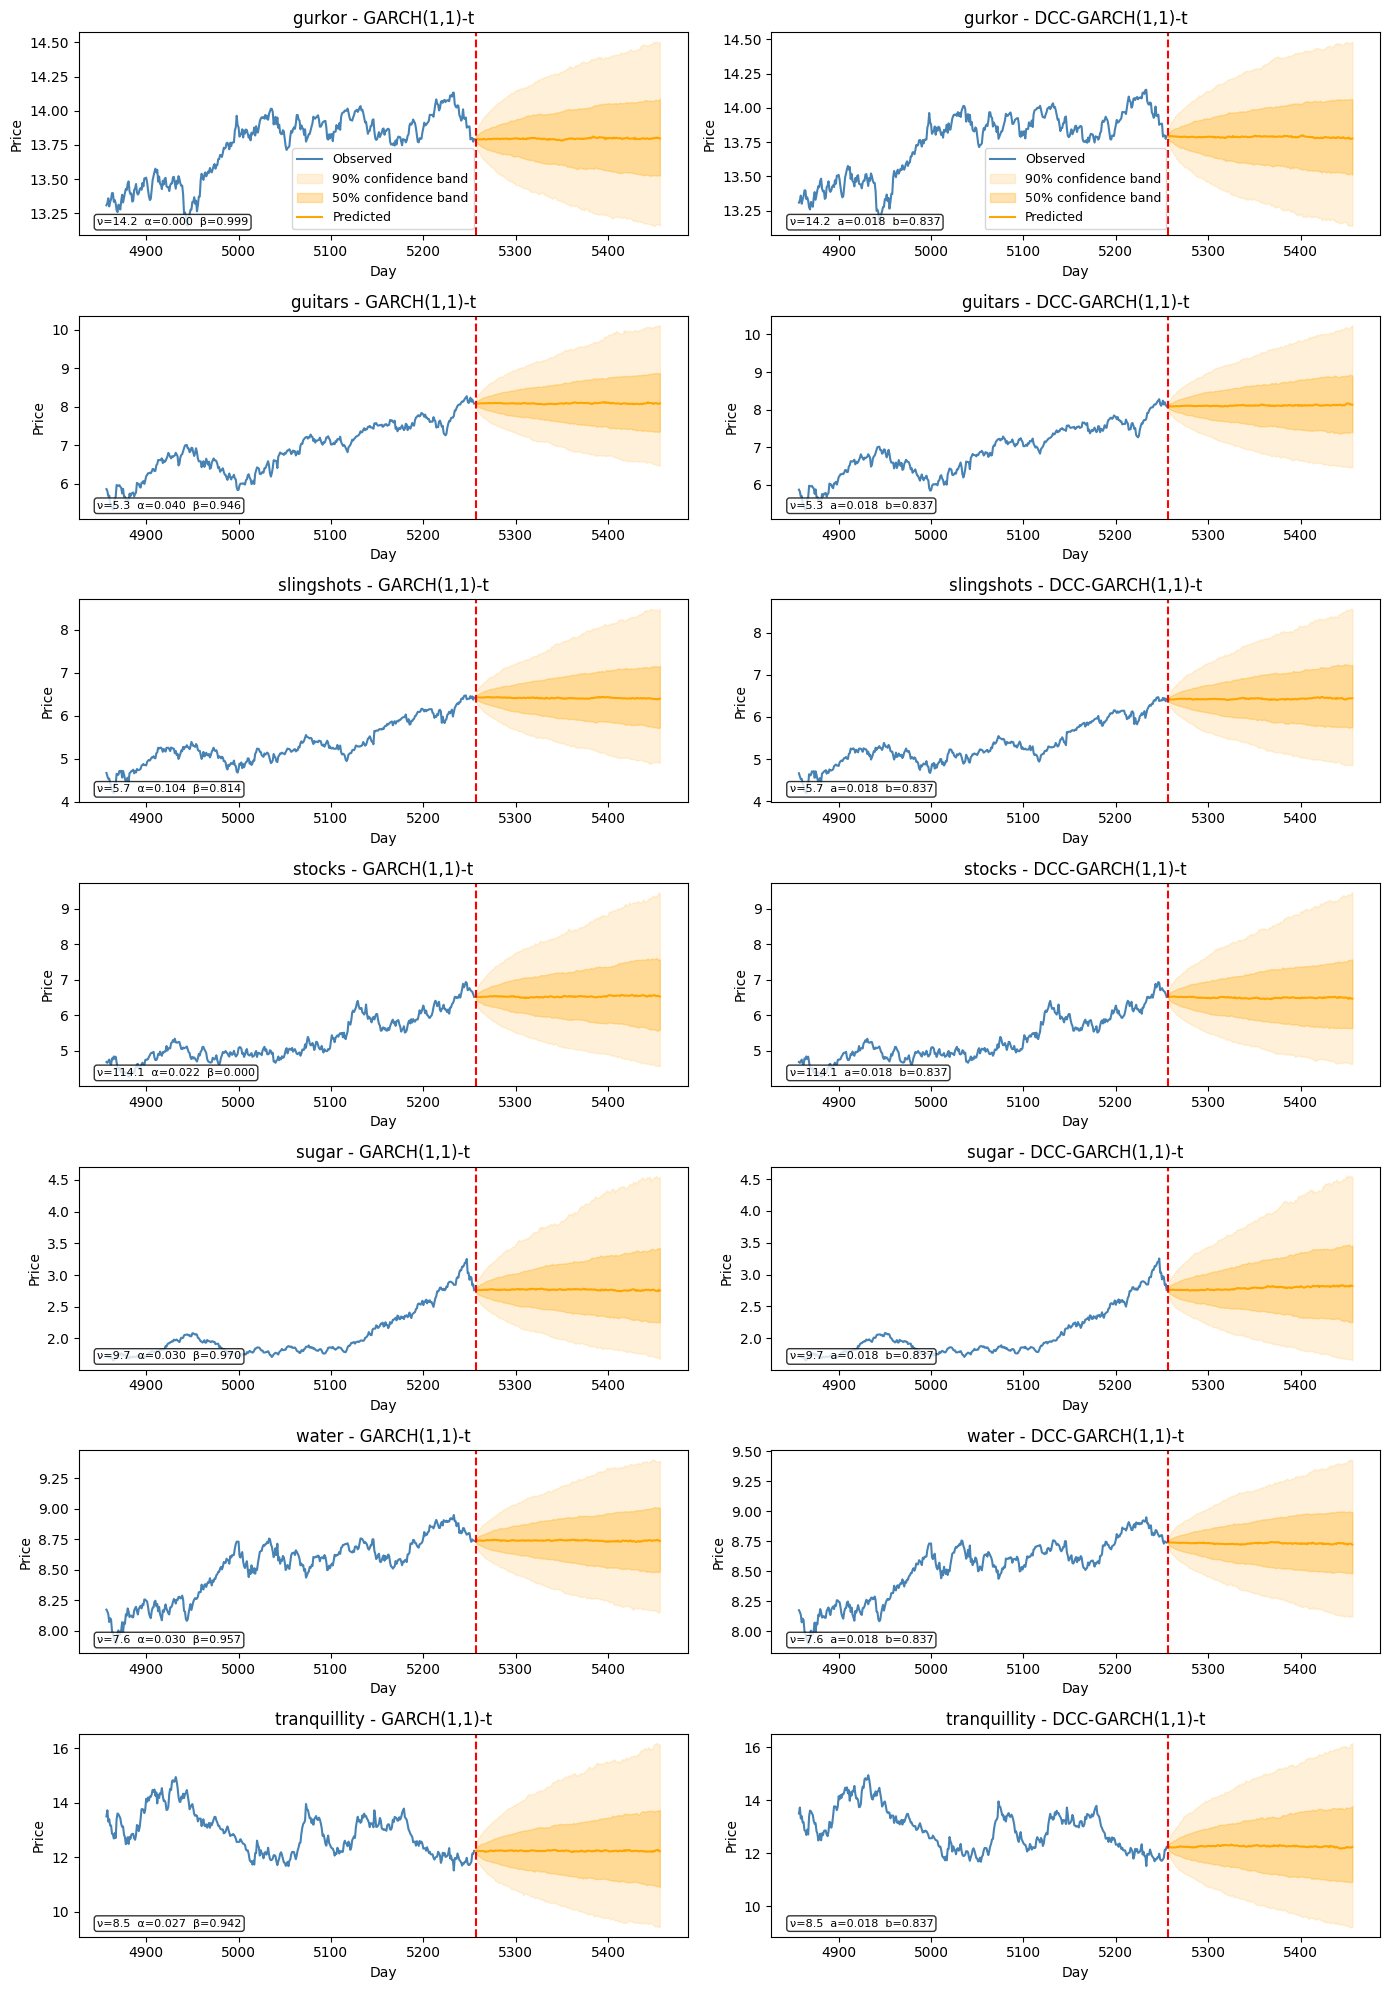

In [7]:
series_list = trailing_gaps["series"].tolist()
fig, axes = plt.subplots(7, 2, figsize=(14, 20))

for row_idx, name in enumerate(series_list):
    gap_row   = trailing_gaps[trailing_gaps["series"] == name].iloc[0]
    gap_start = int(gap_row["start"])
    n_steps   = int(gap_row["length"])

    for col_idx, (res, label) in enumerate([
        (results[name], "GARCH(1,1)-t"),
        (dcc_all[name], "DCC-GARCH(1,1)-t"),
    ]):
        ax      = axes[row_idx, col_idx]
        pct     = res["percentiles"]
        gap_idx = res["gap_index"]
        x_lo    = gap_start - HISTORY_WINDOW

        visible = prices[name].dropna()
        visible = visible[(visible.index >= x_lo) & (visible.index < gap_start)]

        ax.plot(visible.index, visible.values, color="steelblue", label="Observed")
        ax.fill_between(gap_idx, pct["p5"],  pct["p95"], alpha=0.15, color="orange", label="90% confidence band")
        ax.fill_between(gap_idx, pct["p25"], pct["p75"], alpha=0.30, color="orange", label="50% confidence band")
        ax.plot(gap_idx, res["median"], color="orange", label="Predicted")
        ax.axvline(x=gap_start, ls="--", c="r")
        ax.set_title(f"{name} - {label}")
        ax.set_xlabel("Day")
        ax.set_ylabel("Price")

        if col_idx == 0:
            param_txt = (f"\u03bd={res['nu']:.1f}  "
                         f"\u03b1={res.get('alpha', float('nan')):.3f}  "
                         f"\u03b2={res.get('beta', float('nan')):.3f}")
        else:
            param_txt = (f"\u03bd={res['nu']:.1f}  "
                         f"a={res.get('dcc_a', float('nan')):.3f}  "
                         f"b={res.get('dcc_b', float('nan')):.3f}")
        ax.annotate(param_txt, xy=(0.03, 0.04), xycoords="axes fraction",
                    fontsize=8, va="bottom", ha="left",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8))
        if row_idx == 0:
            ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(output_path / "task3_extrapolation_comparison.pdf", bbox_inches="tight")
plt.show()


## Backtesting

Since true trailing values are unknown, performance is evaluated via **pseudo-gaps** carved from the observed region (index >= 1500, past any real internal gaps).

Both methods use the **same 50 randomly drawn pseudo-gap positions** to ensure fair comparison. The DCC fits all series jointly at each backtest position.

| Metric | Meaning |
|---|---|
| MAPE (%) | Mean absolute percentage error of median path |
| RMSE | Absolute error (price units) |
| RMSE log | RMSE in log-price space |
| Coverage 90 / 50 | Fraction of true prices inside the 90% / 50% band |
| End width 90% | Width of 90% band at the final forecast step, as % of price |


In [8]:
def _extrapolation_metrics(true_prices: np.ndarray, result) -> dict:
    """Scalar metrics for one pseudo-gap backtest."""
    median = result["median"]
    pct    = result["percentiles"]
    p5, p25, p75, p95 = (
        pct["p5"].values, pct["p25"].values,
        pct["p75"].values, pct["p95"].values,
    )
    mape     = float(np.mean(np.abs(median - true_prices) / true_prices) * 100)
    rmse     = float(np.sqrt(np.mean((median - true_prices) ** 2)))
    rmse_log = float(np.sqrt(np.mean((np.log(median) - np.log(true_prices)) ** 2)))
    cov90    = float(np.mean((true_prices >= p5)  & (true_prices <= p95)))
    cov50    = float(np.mean((true_prices >= p25) & (true_prices <= p75)))
    mid_end  = (p5[-1] + p95[-1]) / 2
    width90  = float((p95[-1] - p5[-1]) / mid_end * 100)
    return dict(mape_pct=mape, rmse=rmse, rmse_log=rmse_log,
                coverage_90=cov90, coverage_50=cov50, end_width_90_pct=width90)


def compute_shared_starts(
    prices_df: pd.DataFrame, n_backtests: int, n_steps: int,
    start_min: int = 1500, random_seed: int = 42,
) -> np.ndarray:
    """Draw shared backtest window starts used by both GARCH and DCC."""
    rng = np.random.default_rng(random_seed)
    min_last_obs = min(
        int(prices_df[s].dropna().index[-n_steps - 1]) for s in prices_df.columns
    )
    candidates = prices_df.index[
        (prices_df.index >= start_min) & (prices_df.index <= min_last_obs)
    ]
    return np.sort(
        rng.choice(candidates, size=min(n_backtests, len(candidates)), replace=False)
    )


def backtest_fixed_starts(
    method, prices_df: pd.DataFrame, fixed_starts: np.ndarray,
    n_steps: int = 200, calibration_window: int = 400, random_seed: int = 42,
) -> pd.DataFrame:
    """Backtest single-series GARCH on pre-specified windows across all series."""
    rng  = np.random.default_rng(random_seed)
    rows = []
    for s in prices_df.columns:
        obs = prices_df[s].dropna()
        for start in fixed_starts:
            tp = obs[obs.index >= start].iloc[:n_steps].values
            if len(tp) < n_steps:
                continue
            try:
                res = method(
                    prices_df[s], start_day=int(start), n_steps=n_steps,
                    calibration_window=calibration_window, n_simulations=500,
                    random_seed=int(rng.integers(1_000_000)),
                )
                m = _extrapolation_metrics(tp, res)
                m["series"] = s
                rows.append(m)
            except Exception:
                pass
    df = pd.DataFrame(rows)
    metric_cols = ["mape_pct", "rmse", "rmse_log", "coverage_90", "coverage_50", "end_width_90_pct"]
    out = df.groupby("series")[metric_cols].mean()
    out["mape_max"] = df.groupby("series")["mape_pct"].max()
    return out


def backtest_dcc_extrapolation(
    prices_df: pd.DataFrame, fixed_starts: np.ndarray,
    n_steps: int = 200, calibration_window: int = 400, random_seed: int = 42,
) :
    """Backtest DCC-GARCH on the same pre-specified windows. All series fitted jointly."""
    rng          = np.random.default_rng(random_seed)
    series_names = list(prices_df.columns)
    rows, param_rows = [], []
    for start in tqdm(fixed_starts, desc="DCC backtest"):
        truth = {}
        skip  = False
        for s in series_names:
            obs = prices_df[s].dropna()
            tp  = obs[obs.index >= start].iloc[:n_steps].values
            if len(tp) < n_steps:
                skip = True; break
            truth[s] = tp
        if skip:
            continue
        try:
            dcc_res, info = dcc_garch_extrapolation(
                prices_df, start_day=int(start), n_steps=n_steps,
                calibration_window=calibration_window, n_simulations=500,
                random_seed=int(rng.integers(1_000_000)),
            )
            param_rows.append({"start": int(start), "dcc_a": info["dcc_a"],
                               "dcc_b": info["dcc_b"], "persistence": info["persistence"]})
            for s in series_names:
                m = _extrapolation_metrics(truth[s], dcc_res[s])
                m["series"] = s
                rows.append(m)
        except Exception:
            pass
    df = pd.DataFrame(rows)
    metric_cols = ["mape_pct", "rmse", "rmse_log", "coverage_90", "coverage_50", "end_width_90_pct"]
    out = df.groupby("series")[metric_cols].mean()
    out["mape_max"] = df.groupby("series")["mape_pct"].max()
    return out, pd.DataFrame(param_rows)


In [9]:
N_BACKTESTS = 50
N_STEPS     = 200
CAL_WINDOW  = 400

# Both methods use exactly the same 50 pseudo-gap windows
shared_starts = compute_shared_starts(
    prices, n_backtests=N_BACKTESTS, n_steps=N_STEPS, start_min=1500, random_seed=42,
)
print(f"Shared backtest windows: {len(shared_starts)} positions, "
      f"range [{shared_starts[0]}, {shared_starts[-1]}]")

print("\nRunning GARCH backtest...")
garch_bt = backtest_fixed_starts(
    garch_extrapolation, prices, shared_starts,
    n_steps=N_STEPS, calibration_window=CAL_WINDOW, random_seed=42,
)

print("Running DCC-GARCH backtest...")
dcc_bt, dcc_params = backtest_dcc_extrapolation(
    prices, fixed_starts=shared_starts,
    n_steps=N_STEPS, calibration_window=CAL_WINDOW, random_seed=42,
)

print("\n=== DCC parameters across backtest runs ===")
print(dcc_params[["dcc_a", "dcc_b", "persistence"]].describe().round(4))


Shared backtest windows: 50 positions, range [1726, 4947]

Running GARCH backtest...
Running DCC-GARCH backtest...

=== DCC parameters across backtest runs ===
         dcc_a    dcc_b  persistence
count  50.0000  50.0000      50.0000
mean    0.0192   0.4884       0.5076
std     0.0083   0.3198       0.3173
min     0.0045   0.0000       0.0045
25%     0.0137   0.1482       0.1786
50%     0.0190   0.5599       0.5751
75%     0.0243   0.7721       0.8012
max     0.0389   0.9111       0.9265


In [10]:
combined = pd.concat([
    garch_bt[["mape_pct", "coverage_90", "coverage_50", "end_width_90_pct"]].add_prefix("garch_"),
    dcc_bt  [["mape_pct", "coverage_90", "coverage_50", "end_width_90_pct"]].add_prefix("dcc_"),
], axis=1)

print("=== MAPE (%) ===")
display(combined[["garch_mape_pct", "dcc_mape_pct"]].round(3))

print("\n=== Coverage 90% (target 0.90) ===")
display(combined[["garch_coverage_90", "dcc_coverage_90"]].round(3))

print("\n=== Coverage 50% (target 0.50) ===")
display(combined[["garch_coverage_50", "dcc_coverage_50"]].round(3))

print("\n=== 90% band end width (%) ===")
display(combined[["garch_end_width_90_pct", "dcc_end_width_90_pct"]].round(2))

# DCC vs GARCH improvement
error_cols = ["mape_pct", "rmse", "rmse_log", "end_width_90_pct"]
cov_cols   = ["coverage_90", "coverage_50"]
imp = pd.DataFrame(index=garch_bt.index)
for c in error_cols:
    imp[c] = (garch_bt[c] - dcc_bt[c]) / garch_bt[c] * 100
for c in cov_cols:
    imp[c] = dcc_bt[c] - garch_bt[c]
print("\n=== DCC improvement over GARCH (positive = DCC better) ===")
display(imp.round(3))


=== MAPE (%) ===


,garch_mape_pct,dcc_mape_pct
series,,
guitars,11.743,11.807
gurkor,3.270,3.268
slingshots,11.156,11.179
stocks,11.765,11.696
sugar,11.966,12.024
tranquillity,12.823,12.871
water,2.952,2.977



=== Coverage 90% (target 0.90) ===


,garch_coverage_90,dcc_coverage_90
series,,
guitars,0.863,0.855
gurkor,0.871,0.862
slingshots,0.912,0.909
stocks,0.914,0.917
sugar,0.877,0.867
tranquillity,0.861,0.859
water,0.817,0.794



=== Coverage 50% (target 0.50) ===


,garch_coverage_50,dcc_coverage_50
series,,
guitars,0.502,0.489
gurkor,0.460,0.451
slingshots,0.546,0.541
stocks,0.471,0.477
sugar,0.525,0.485
tranquillity,0.487,0.486
water,0.409,0.398



=== 90% band end width (%) ===


,garch_end_width_90_pct,dcc_end_width_90_pct
series,,
guitars,66.05,64.44
gurkor,19.42,19.00
slingshots,70.61,69.53
stocks,65.82,65.83
sugar,69.13,65.91
tranquillity,61.21,60.69
water,16.42,15.44



=== DCC improvement over GARCH (positive = DCC better) ===


,mape_pct,rmse,rmse_log,end_width_90_pct,coverage_90,coverage_50
series,,,,,,
guitars,-0.546,-0.331,-0.315,2.440,-0.008,-0.013
gurkor,0.047,-0.045,-0.047,2.135,-0.009,-0.009
slingshots,-0.204,0.041,-0.152,1.522,-0.003,-0.005
stocks,0.585,0.520,0.559,-0.012,0.003,0.006
sugar,-0.486,-0.596,-0.464,4.668,-0.010,-0.040
tranquillity,-0.373,0.081,-0.057,0.850,-0.002,-0.002
water,-0.842,-0.994,-0.768,5.969,-0.023,-0.011


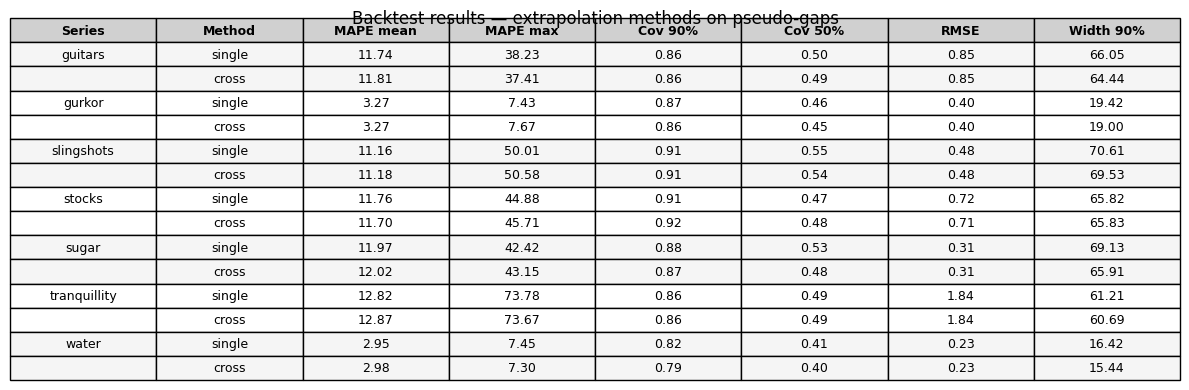

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

series_list = sorted(garch_bt.index)
col_labels  = ["Series", "Method", "MAPE mean", "MAPE max", "Cov 90%", "Cov 50%", "RMSE", "Width 90%"]
col_keys    = ["mape_pct", "mape_max", "coverage_90", "coverage_50", "rmse", "end_width_90_pct"]

rows = []
for series in series_list:
    g = garch_bt.loc[series]
    d = dcc_bt.loc[series]
    rows.append([series, "single"] + [f"{g[k]:.2f}" for k in col_keys])
    rows.append(["",     "cross" ] + [f"{d[k]:.2f}" for k in col_keys])

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Bold header
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#d0d0d0")
    table[0, j].set_text_props(fontweight="bold")

# Light grey for every other series pair
for i, series in enumerate(series_list):
    color = "#f5f5f5" if i % 2 == 0 else "white"
    for row in [i * 2 + 1, i * 2 + 2]:
        for j in range(len(col_labels)):
            table[row, j].set_facecolor(color)

plt.title("Backtest results — extrapolation methods on pseudo-gaps", pad=12)
plt.tight_layout()
plt.savefig("task3_results_table.pdf", bbox_inches="tight", dpi=150)
plt.show()